# Prepare Magusson Data if needed

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import HNW_validation.HNW_validation_helper as val_helper

infile = "/Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/validation_input_Mag25/Mag25_all.nc"
csv_file = "/Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/dSnow/validated_data/Mag25_SWE_mod_from_R_dyn_rho_max.csv"
outfile = "/Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/dSnow/validated_data/Mag25_dSnow_all_stations_final_R_dyn_rho_max.nc"

# load original dataset
ds = xr.open_dataset(infile)

# read CSV from R
SWE_mod = pd.read_csv(csv_file).to_numpy()

# R matrix is station x time -> xarray needs time x station
SWE_mod = SWE_mod.T

# safety check
assert SWE_mod.shape == (ds.sizes["time"], ds.sizes["station"])

# add variable
ds["SWE_mod"] = xr.DataArray(
    SWE_mod,
    coords={"time": ds["time"], "station": ds["station"]},
    dims=("time", "station"),
)

ds.to_netcdf(outfile)


In [158]:
# Filter stations below 2000m altitude
low_altitude_mask = ds.altitude.values < 2000
Mag25_data_with_SWE = ds.isel(station=low_altitude_mask)

print(f"Stations below 2000m: {Mag25_data_with_SWE.sizes['station']}")
print(Mag25_data_with_SWE.station.values)

Stations below 2000m: 39
['Adelboden' 'Gadmen' 'Grindelwald_Bort' 'Gsteig' 'Gantrisch' 'Leysin'
 'Muerren' 'Saanenmoeser' 'Wengen' 'Srenberg' 'Stoos' 'Braunwald' 'Malbun'
 'St_Margrethenberg' 'Binn' 'Bourg_St_Pierre' 'Fionnay' 'Grimentz'
 'Lauchernalp' 'Montana' 'Muenster' 'Saas_Fee' 'Simplon_Dorf' 'Ulrichen'
 'Wiler' 'Bivio' 'Davos_Flueelastr' 'Obersaxen' 'Pusserein' 'St_Antoenien'
 'Sedrun' 'Spluegen' 'Vals' 'Bosco_Gurin' 'San_Bernadino' 'Maloja'
 'Sankt_Moritz' 'Samnaun' 'Zuoz']


In [159]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os


def _filter_season(df, full_season=False):
    """Filter DataFrame to snow season (Nov 1 – Apr 30) unless full_season=True."""
    
    df = _set_datime_index(df)

    mask = (df.index.month >= 11) | (df.index.month <= 4)
    return df.loc[mask].copy()

def _set_datime_index(df):
    """Ensure DataFrame has a DatetimeIndex."""
    
    df.index = pd.to_datetime(df.time)
    return df


def _calculate_metrics(x, y):
    """
    Calculate validation metrics.
    x = observed
    y = modeled
    """

    residuals = y - x

    rmse = np.sqrt(np.mean(residuals**2))
    bias = np.mean(residuals)
    pbias = np.sum(residuals) / np.sum(x) if np.sum(x) != 0 else np.nan

    ss_res = np.sum((x - y)**2)
    ss_tot = np.sum((x - np.mean(x))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return {
        "RMSE": rmse,
        "Bias": bias,
        "Rel_BIAS": pbias,
        "R2": r2
    }


def _plot_validation(x, y, stats, model_name, lim, xlabel, ylabel):
    """
    Generic validation density plot.
    """

    plt.figure(figsize=(8, 7))

    plt.hist2d(
        x, y,
        bins=50,
        range=[lim, lim],
        norm=LogNorm(vmin=1, vmax=1000),
        cmap="jet"
    )

    cb = plt.colorbar(label="Number of observations")
    cb.set_ticks([1, 10, 100, 1000])
    cb.set_ticklabels(["1", "10", "100", ">999"])

    plt.plot(lim, lim, "--", color="gray", linewidth=1.3)

    ticks = np.linspace(lim[0], lim[1], 5)
    plt.xticks(ticks)
    plt.yticks(ticks)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(model_name, fontsize=15)

    textstr = (
        f"$R^2$: {stats['R2']:.2f}\n"
        f"Bias: {stats['Bias']:.2f}\n"
        f"RMSE: {stats['RMSE']:.1f}"
    )

    plt.text(
        0.03, 0.97, textstr,
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    plt.xlim(lim)
    plt.ylim(lim)

    plt.grid(False)
    plt.tight_layout()


def validate_hnw_mag25(df,
                       model_name,
                       obs_col="HNW_obs",
                       mod_col="HNW_mod",
                       save_dir=None,
                       filename="hnw_validation.png",
                       full_season=False):

    df = _filter_season(df, full_season)

    df_valid = df.dropna(subset=[obs_col, mod_col])

    # Caution greate differnce if it is >= 0 or > 0
    df_valid = df_valid[df_valid[obs_col] >= 0]

    df_valid = df_valid[
        np.isfinite(df_valid[obs_col]) &
        np.isfinite(df_valid[mod_col])
    ]

    x = df_valid[obs_col].values
    y = df_valid[mod_col].values

    stats = _calculate_metrics(x, y)
    stats["N"] = len(df_valid)

    print(stats)

    _plot_validation(
        x,
        y,
        stats,
        model_name,
        lim=[0, 100],
        xlabel="Observed HNW (mm)",
        ylabel="Modeled HNW (mm)"
    )

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, filename)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Plot saved to: {save_path}")

    plt.show()

    return stats


def validate_swe_mag25(df,
                       model_name,
                       obs_col="SWE_obs",
                       mod_col="SWE_mod",
                       save_dir=None,
                       filename="swe_validation.png",
                       full_season=False):

    df = _filter_season(df, full_season)

    df_valid = df.dropna(subset=[obs_col, mod_col])
    df_valid = df_valid[df_valid[obs_col] >= 0]

    print(f"Number of valid observations after filtering: {len(df_valid)}")

    df_valid = df_valid[
        np.isfinite(df_valid[obs_col]) &
        np.isfinite(df_valid[mod_col])
    ]

    x = df_valid[obs_col].values
    y = df_valid[mod_col].values

    stats = _calculate_metrics(x, y)
    stats["N"] = len(df_valid)

    print(stats)

    _plot_validation(
        x,
        y,
        stats,
        model_name,
        lim=[0, 1000],
        xlabel="Observed SWE (mm)",
        ylabel="Modeled SWE (mm)"
    )

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, filename)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Plot saved to: {save_path}")

    plt.show()

    return stats

In [160]:
# Calculate day-to-day SWE increase
HNW_mod = Mag25_data_with_SWE["SWE_mod"].diff(dim="time")

# Clip negative values to 0
HNW_mod = HNW_mod.clip(min=0)

# Reindex back to the original time axis
HNW_mod = HNW_mod.reindex(time=Mag25_data_with_SWE["time"])

# Add to dataset
Mag25_data_with_SWE["HNW_mod"] = HNW_mod

Number of valid observations after filtering: 957
{'RMSE': np.float64(36.74812547148213), 'Bias': np.float64(5.3420632748509655), 'Rel_BIAS': np.float64(0.02638945152788237), 'R2': np.float64(0.9074845473093048), 'N': 957}
Plot saved to: HNW_validation/dSnow/validation_plots/deltasnow_SWE_validation_R_dyn_rho_max_maxalt_2000.png


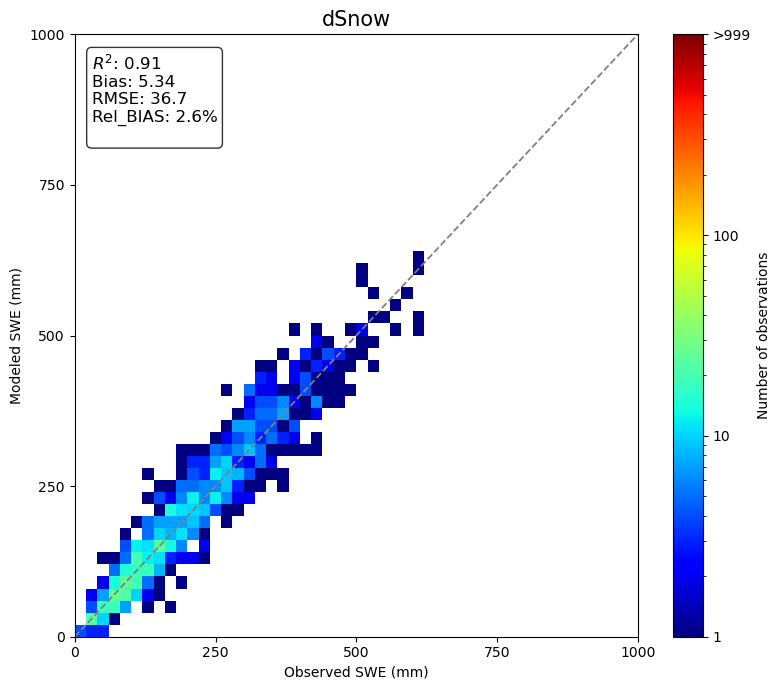

{'RMSE': np.float64(36.74812547148213),
 'Bias': np.float64(5.3420632748509655),
 'Rel_BIAS': np.float64(0.02638945152788237),
 'R2': np.float64(0.9074845473093048),
 'N': 957}

In [170]:
all_df_SWE = Mag25_data_with_SWE[["SWE", "SWE_mod"]].to_dataframe().reset_index()
all_df_SWE = all_df_SWE.rename(columns={
    "SWE": "SWE_obs",
    "SWE_mod": "SWE_mod"
})

all_df_SWE.index = all_df_SWE.index.astype("datetime64[ns]")

val_helper.validate_swe_mag25(all_df_SWE, 
                              model_name="dSnow",
                              save_dir="HNW_validation/dSnow/validation_plots",
                              filename="deltasnow_SWE_validation_R_dyn_rho_max_maxalt_2000.png")